## 1. Environment Setup and Library Imports

In [1]:
from pathlib import Path
import os
import sys
import json
import platform
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import norm

## 2. Configuration and Output Directory Initialization

In [2]:
SEED = 42
np.random.seed(SEED)

OUT_DIR = Path('output')
ANALYSIS_DIR = OUT_DIR / 'analysis'
OUT_DIR.mkdir(exist_ok=True, parents=True)
ANALYSIS_DIR.mkdir(exist_ok=True, parents=True)

CONFIG = {
    'dataset': 'City of Chicago Reported Crimes (Socrata Open Data API)',
    'api_endpoint': 'https://data.cityofchicago.org/resource/ijzp-q8t2.json',
    'primary_district': '001',
    'secondary_district': '018',
    'start_date': '2021-01-01T00:00:00.000',
    'end_date': '2024-12-31T23:59:59.000',
    'date_col': 'date',
    'location_col': 'district',
    'frequency': 'W-MON',
    'test_periods': 12,
    'ar_lags': 4,
    'seed': SEED
}
CONFIG

{'dataset': 'City of Chicago Reported Crimes (Socrata Open Data API)',
 'api_endpoint': 'https://data.cityofchicago.org/resource/ijzp-q8t2.json',
 'primary_district': '001',
 'secondary_district': '018',
 'start_date': '2021-01-01T00:00:00.000',
 'end_date': '2024-12-31T23:59:59.000',
 'date_col': 'date',
 'location_col': 'district',
 'frequency': 'W-MON',
 'test_periods': 12,
 'ar_lags': 4,
 'seed': 42}

## 3. Data Ingestion via Socrata Public API

In [3]:
params = {
    "$limit": 50000,
    "$where": f"date >= '{CONFIG['start_date']}' and date <= '{CONFIG['end_date']}' and (district='{CONFIG['primary_district']}' or district='{CONFIG['secondary_district']}')",
    "$order": "date ASC"
}

resp = requests.get(CONFIG['api_endpoint'], params=params, timeout=45)
df = pd.DataFrame(resp.json())
df[CONFIG['date_col']] = pd.to_datetime(df[CONFIG['date_col']], errors='coerce')
df = df.dropna(subset=[CONFIG['date_col']]).copy()
df['district'] = df['district'].astype(str).str.zfill(3)

print("Ingested Records Shape:", df.shape)
df[['date', 'district', 'primary_type', 'description']].head()

Ingested Records Shape: (50000, 22)


,date,district,primary_type,description
0,2021-01-01,018,BATTERY,SIMPLE
1,2021-01-01,018,DECEPTIVE PRACTICE,EMBEZZLEMENT
2,2021-01-01,018,THEFT,FROM BUILDING
3,2021-01-01,018,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED
4,2021-01-01,001,DECEPTIVE PRACTICE,COMPUTER FRAUD


## 4. Regular Time-Series Construction and Resampling

In [4]:
def build_series(data, dist_code, freq):
    sub = data[data['district'] == dist_code].copy()
    ts = (sub.set_index('date')
             .resample(freq)
             .size()
             .rename('incidents')
             .asfreq(freq, fill_value=0))
    return ts

y_d1 = build_series(df, CONFIG['primary_district'], CONFIG['frequency']).iloc[:-1]
y_d18 = build_series(df, CONFIG['secondary_district'], CONFIG['frequency']).iloc[:-1]

assert y_d1.index.is_monotonic_increasing
assert y_d1.index.is_unique
assert y_d1.isna().sum() == 0

print("Primary Series Summary (District 1):")
y_d1.describe()

Primary Series Summary (District 1):


count    114.000000
mean     215.991228
std       76.100829
min       69.000000
25%      181.000000
50%      218.000000
75%      247.750000
max      706.000000
Name: incidents, dtype: float64

## 5. Chronological Train-Test Partitioning

In [5]:
H = CONFIG['test_periods']
train_d1, test_d1 = y_d1.iloc[:-H], y_d1.iloc[-H:]

print(f"Total Periods: {len(y_d1)}")
print(f"Training Range: {train_d1.index.min().date()} to {train_d1.index.max().date()} (N={len(train_d1)})")
print(f"Testing Range:  {test_d1.index.min().date()} to {test_d1.index.max().date()} (N={len(test_d1)})")

def score_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'MAE': float(mae), 'RMSE': float(rmse)}

Total Periods: 114
Training Range: 2021-01-04 to 2022-12-12 (N=102)
Testing Range:  2022-12-19 to 2023-03-06 (N=12)


## 6. Visualizing Raw Incident Series and Partition Split

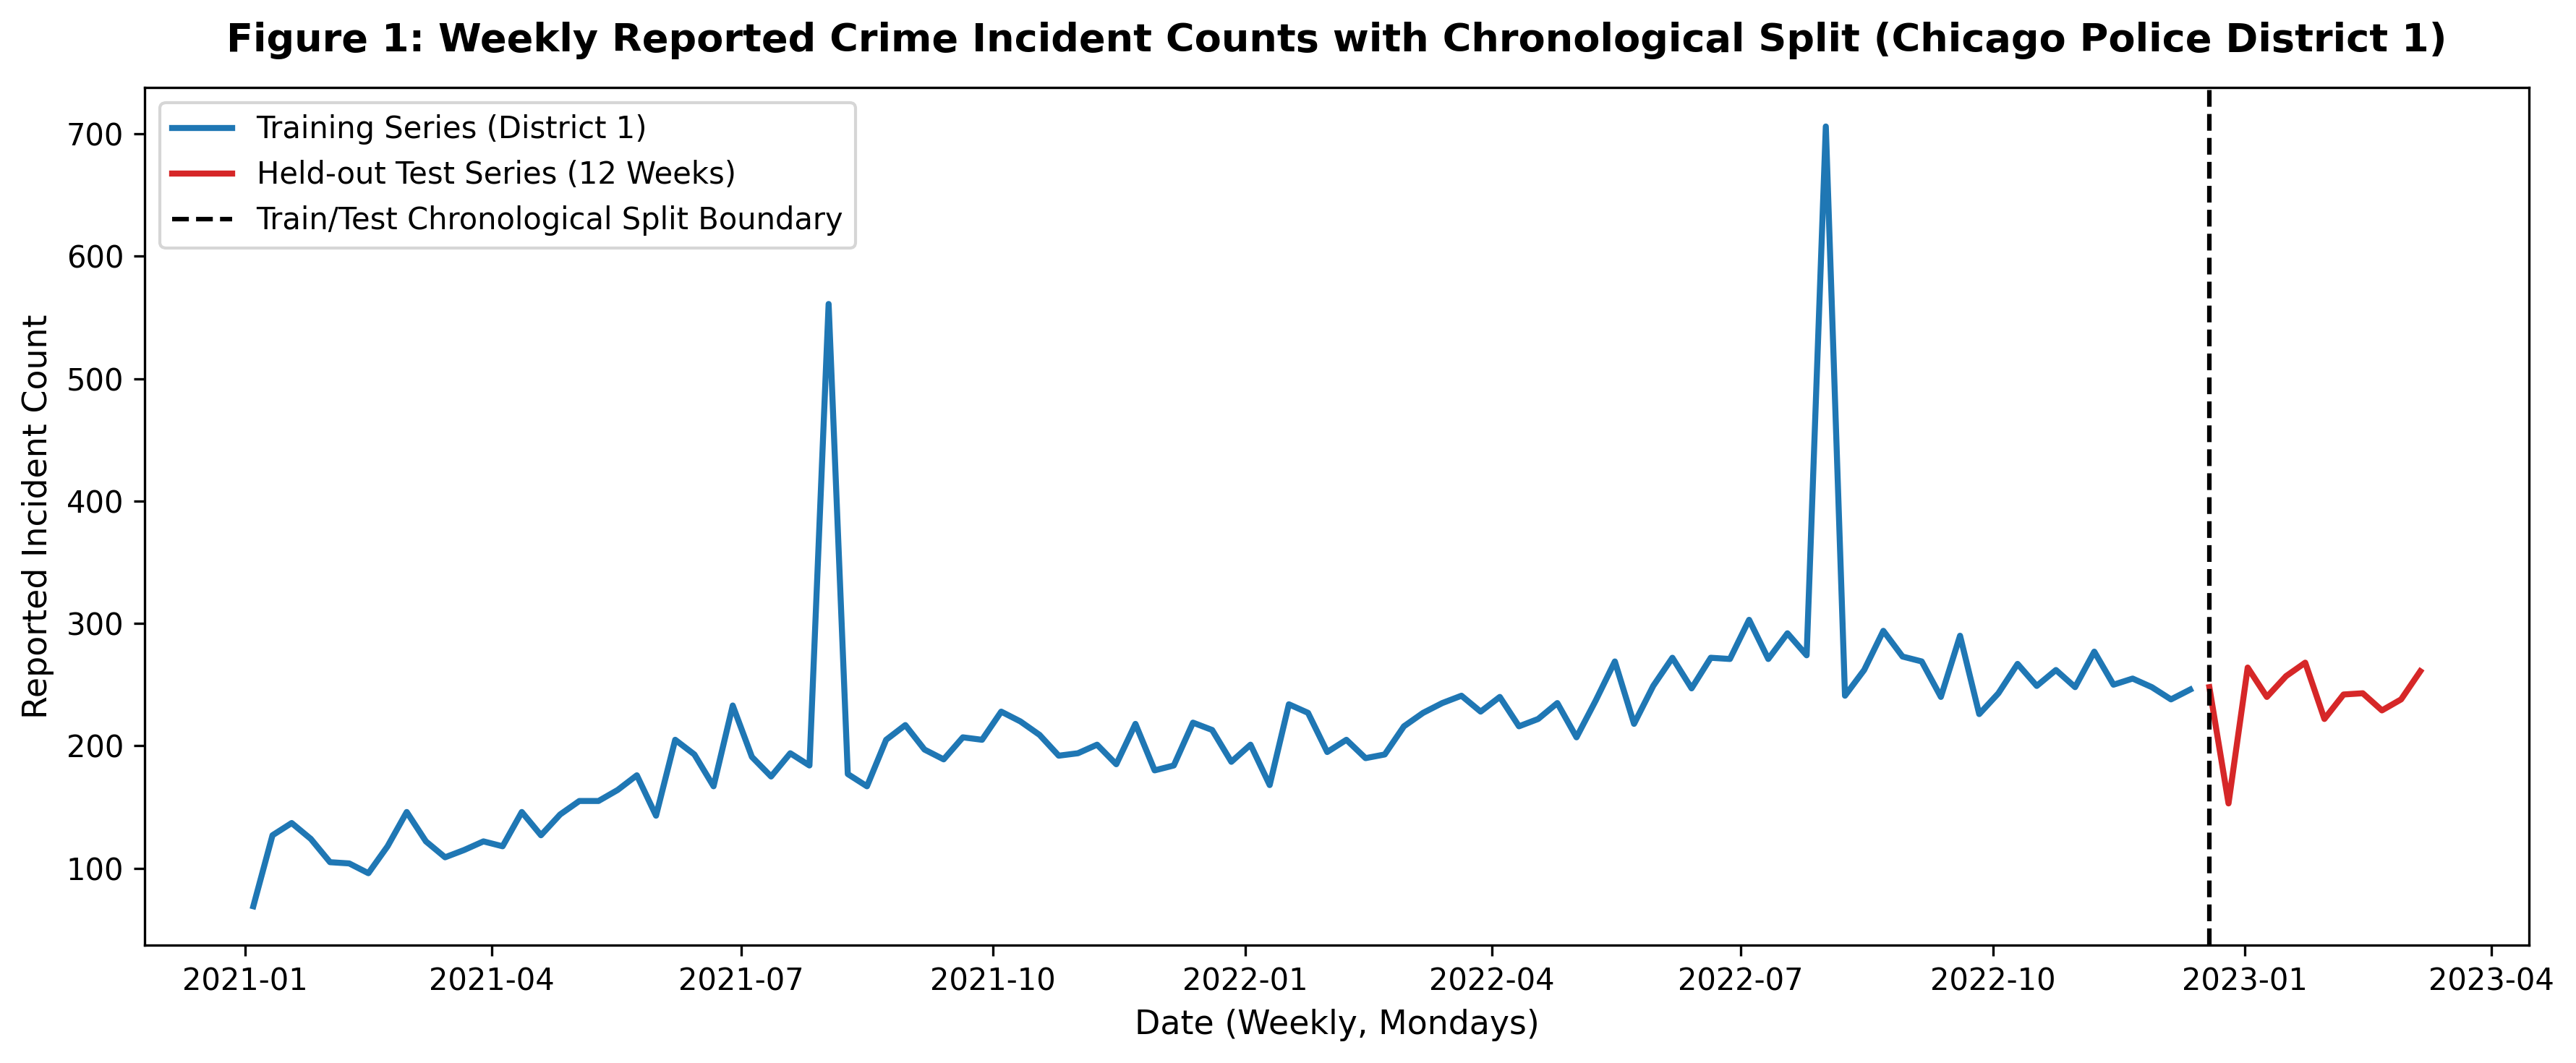

In [6]:
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(train_d1.index, train_d1.values, label='Training Series (District 1)', color='#1f77b4', lw=2)
plt.plot(test_d1.index, test_d1.values, label='Held-out Test Series (12 Weeks)', color='#d62728', lw=2)
plt.axvline(x=test_d1.index[0], color='black', linestyle='--', lw=1.5, label='Train/Test Chronological Split Boundary')
plt.title('Figure 1: Weekly Reported Crime Incident Counts with Chronological Split (Chicago Police District 1)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Date (Weekly, Mondays)', fontsize=11)
plt.ylabel('Reported Incident Count', fontsize=11)
plt.legend(frameon=True, facecolor='white', loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_raw_timeseries_split.png')
plt.show()

## 7. Rolling Statistics and Volatility Dynamics

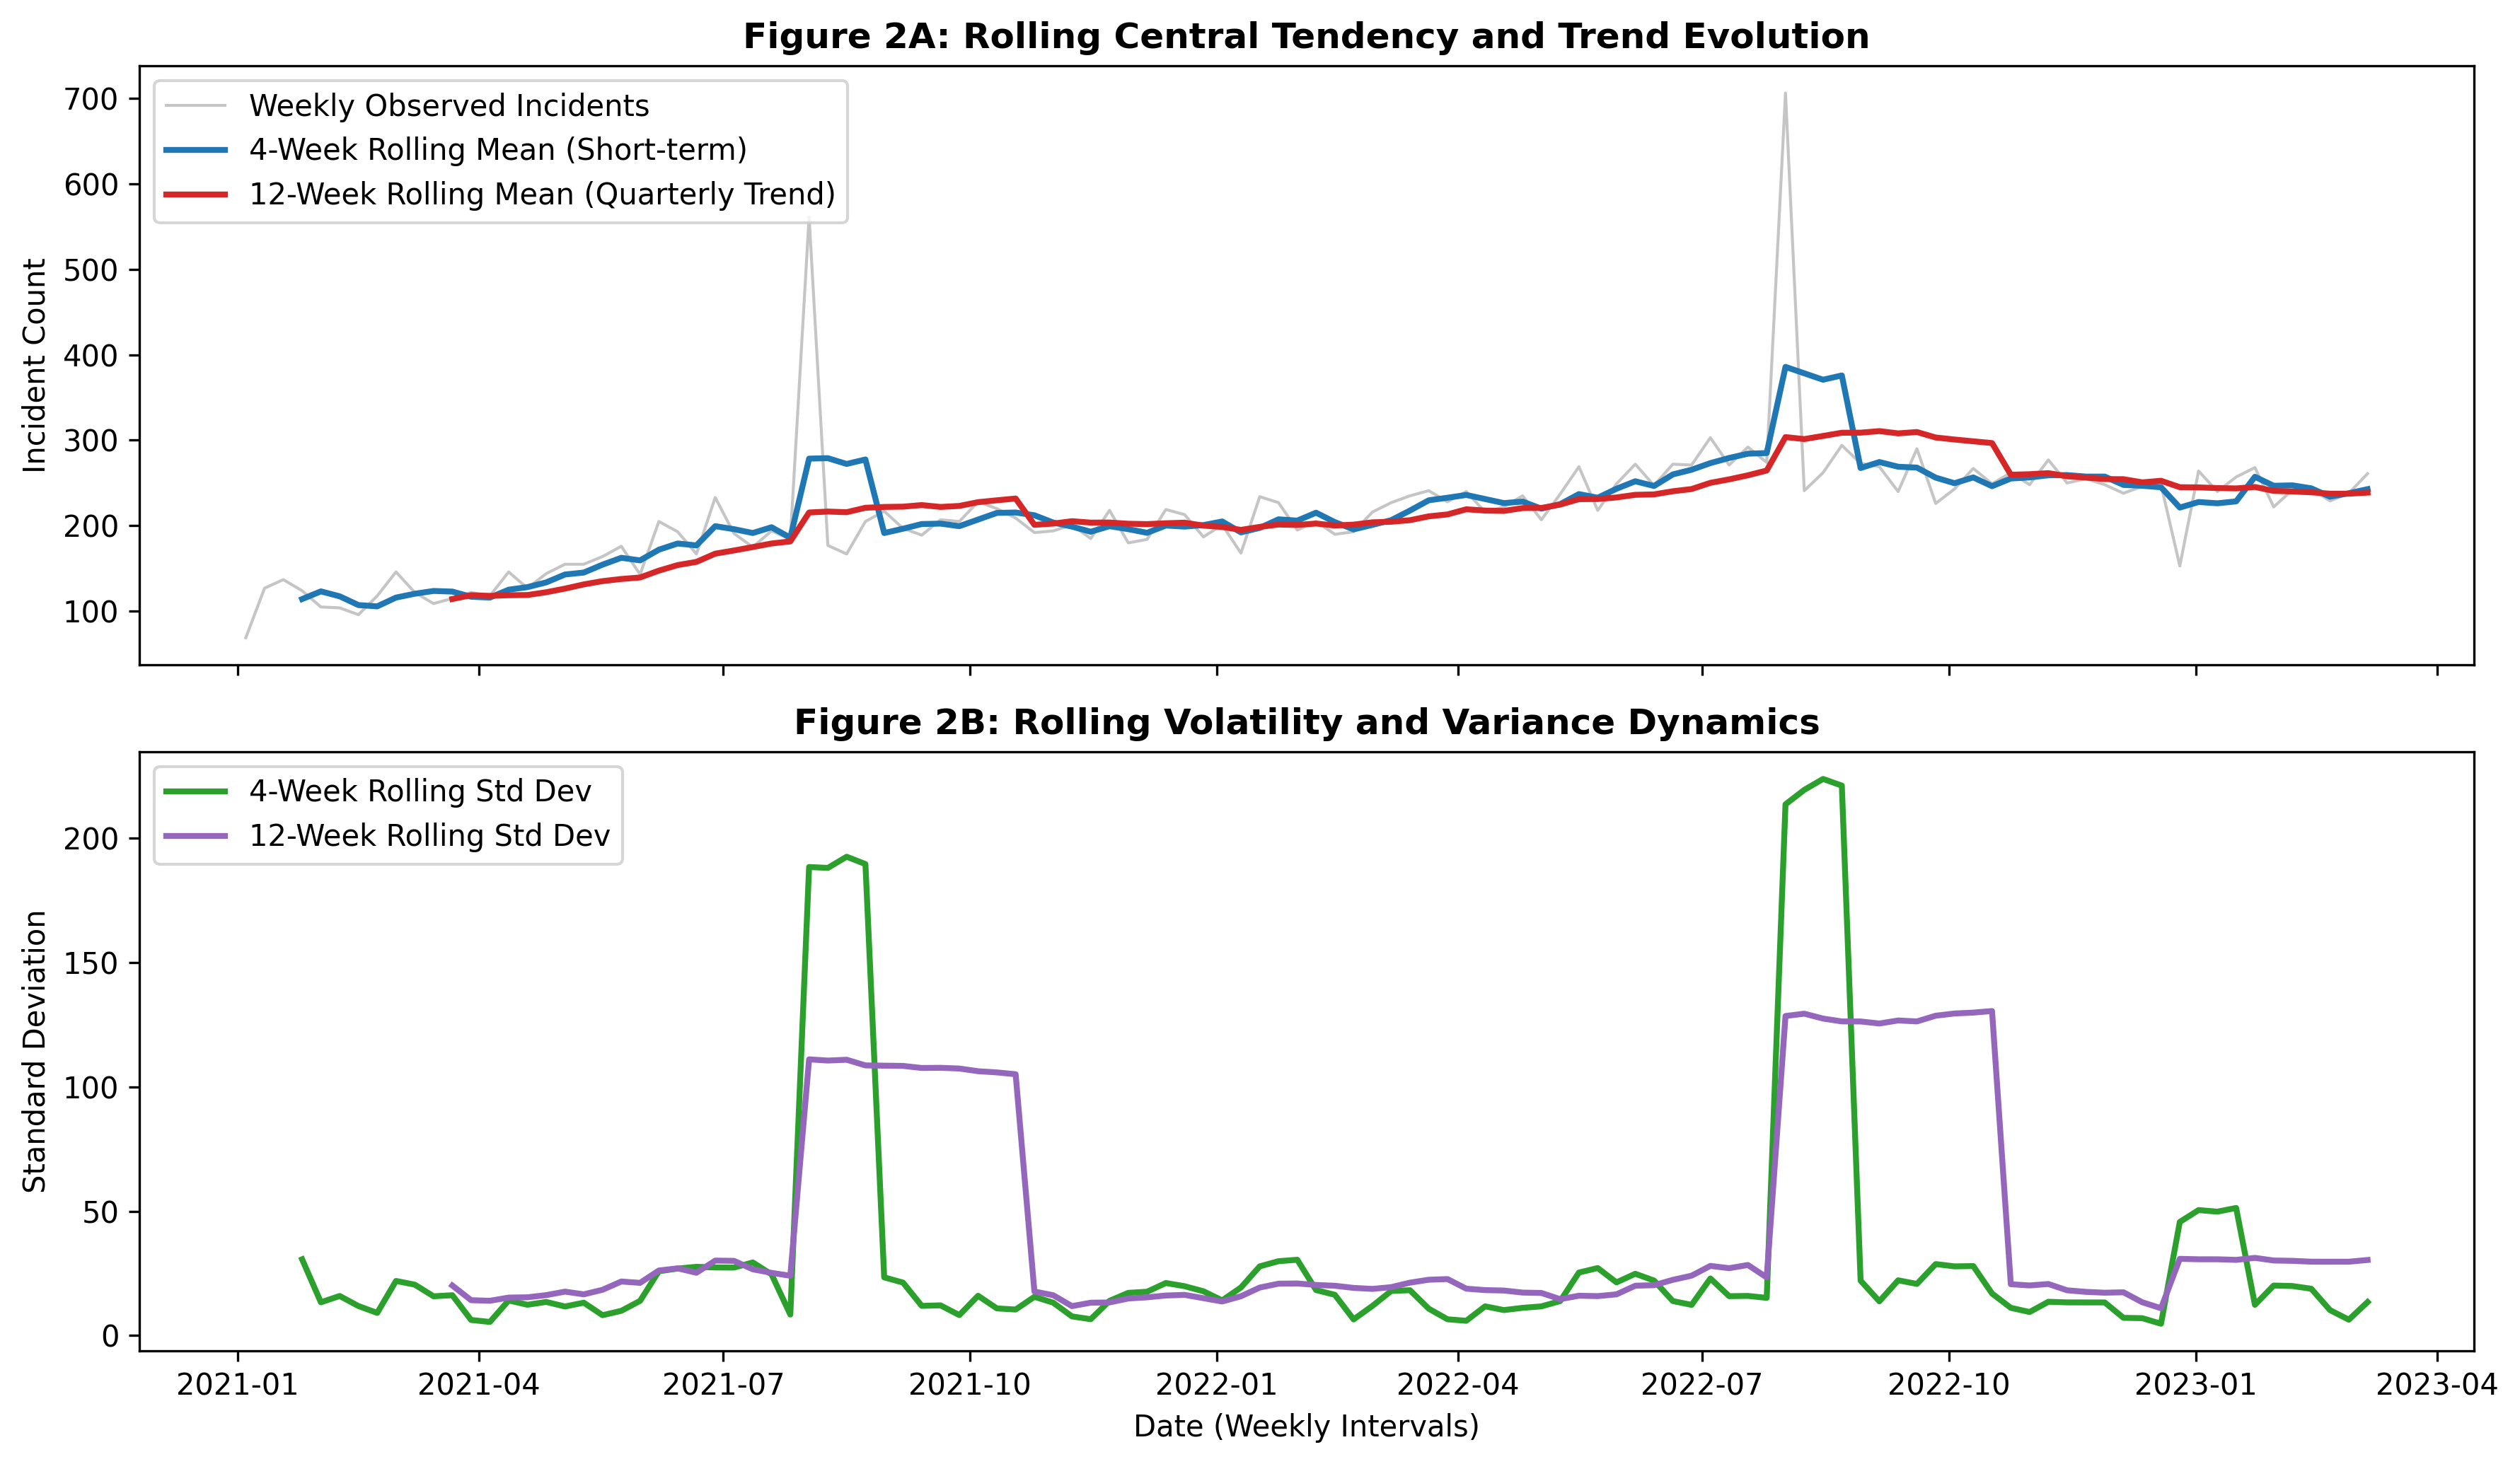

In [7]:
roll_mean_4 = y_d1.rolling(window=4).mean()
roll_std_4 = y_d1.rolling(window=4).std()
roll_mean_12 = y_d1.rolling(window=12).mean()
roll_std_12 = y_d1.rolling(window=12).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 7), dpi=300, sharex=True)
ax[0].plot(y_d1.index, y_d1.values, label='Weekly Observed Incidents', color='#7f7f7f', alpha=0.45, lw=1)
ax[0].plot(roll_mean_4.index, roll_mean_4.values, label='4-Week Rolling Mean (Short-term)', color='#1f77b4', lw=2)
ax[0].plot(roll_mean_12.index, roll_mean_12.values, label='12-Week Rolling Mean (Quarterly Trend)', color='#d62728', lw=2)
ax[0].set_title('Figure 2A: Rolling Central Tendency and Trend Evolution', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Incident Count', fontsize=10)
ax[0].legend(frameon=True, facecolor='white', loc='upper left')

ax[1].plot(roll_std_4.index, roll_std_4.values, label='4-Week Rolling Std Dev', color='#2ca02c', lw=2)
ax[1].plot(roll_std_12.index, roll_std_12.values, label='12-Week Rolling Std Dev', color='#9467bd', lw=2)
ax[1].set_title('Figure 2B: Rolling Volatility and Variance Dynamics', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Date (Weekly Intervals)', fontsize=10)
ax[1].set_ylabel('Standard Deviation', fontsize=10)
ax[1].legend(frameon=True, facecolor='white', loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig02_rolling_stats.png')
plt.show()

## 8. Stationarity and Lag Diagnostics (ADF, ACF, PACF)

C:\Users\mribl\AppData\Local\Temp\ipykernel_3264\1965754508.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(train_d1, autolag='AIC')


ADF Statistic: -2.0856
ADF p-value:   0.2504
Critical Values: {'1%': np.float64(-3.4996365338407074), '5%': np.float64(-2.8918307730370025), '10%': np.float64(-2.5829283377617176)}


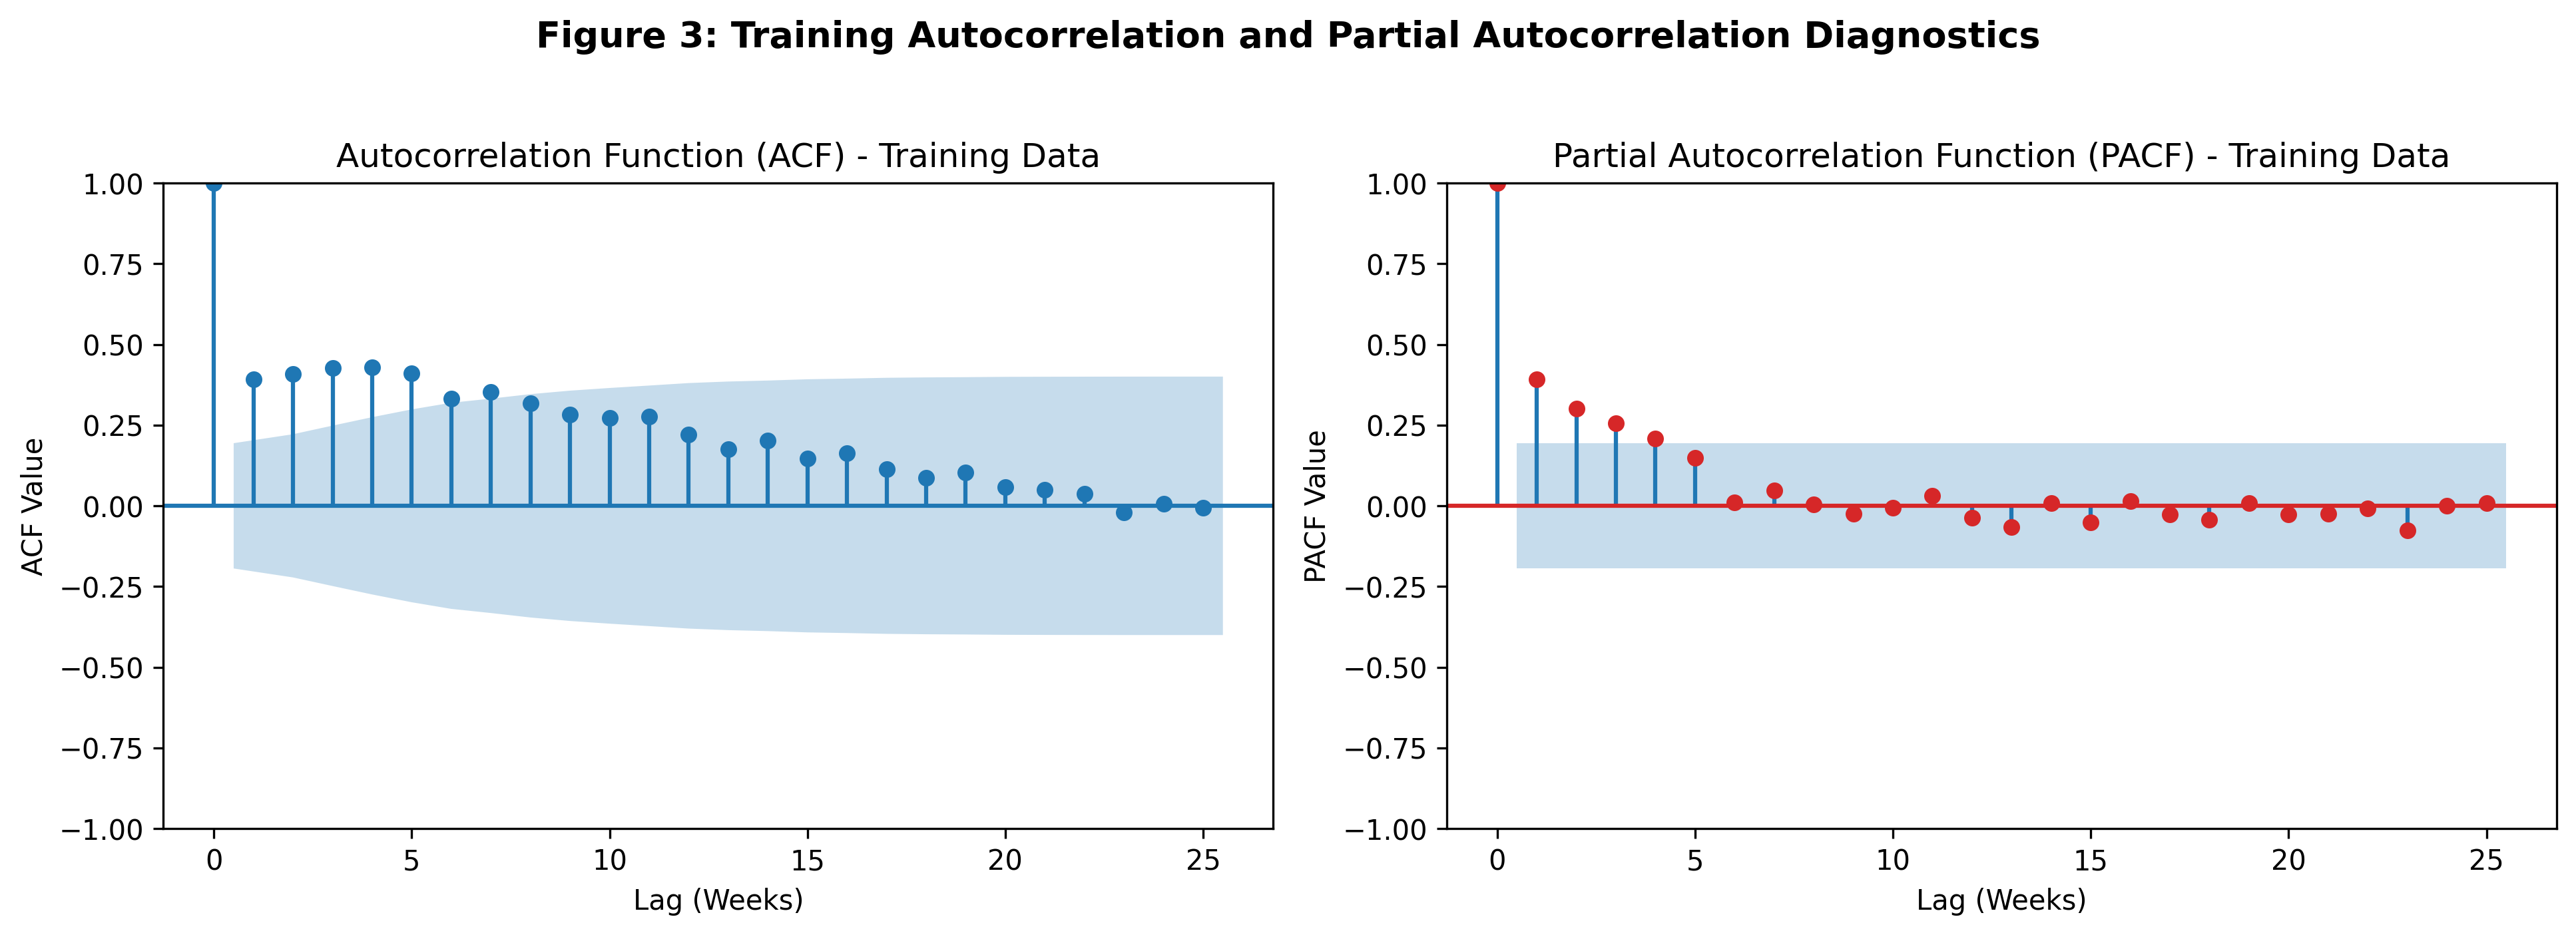

In [8]:
adf_res = adfuller(train_d1, autolag='AIC')
print(f"ADF Statistic: {adf_res[0]:.4f}")
print(f"ADF p-value:   {adf_res[1]:.4f}")
print("Critical Values:", adf_res[4])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), dpi=300)
lags_plot = min(30, len(train_d1) // 4)
plot_acf(train_d1, lags=lags_plot, ax=ax[0], color='#1f77b4', title='Autocorrelation Function (ACF) - Training Data')
plot_pacf(train_d1, lags=lags_plot, ax=ax[1], color='#d62728', method='ywm', title='Partial Autocorrelation Function (PACF) - Training Data')
ax[0].set_xlabel('Lag (Weeks)', fontsize=10)
ax[0].set_ylabel('ACF Value', fontsize=10)
ax[1].set_xlabel('Lag (Weeks)', fontsize=10)
ax[1].set_ylabel('PACF Value', fontsize=10)
plt.suptitle('Figure 3: Training Autocorrelation and Partial Autocorrelation Diagnostics', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig03_training_acf_pacf.png')
plt.show()

## 9. Baseline Naive Model and Autoregressive (AR) Model

In [9]:
naive_val = train_d1.iloc[-1]
naive_pred = np.repeat(naive_val, len(test_d1))
naive_metrics = score_metrics(test_d1, naive_pred)

ar_model_fit = AutoReg(train_d1, lags=CONFIG['ar_lags'], trend='ct').fit()
ar_pred = ar_model_fit.predict(start=len(train_d1), end=len(train_d1) + len(test_d1) - 1, dynamic=False)
ar_metrics = score_metrics(test_d1, ar_pred)
ar_resid = ar_model_fit.resid.dropna()
ar_lb_p = float(acorr_ljungbox(ar_resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0])

print("Naive Baseline:", naive_metrics)
print(f"AR({CONFIG['ar_lags']}) Metrics:", ar_metrics)
print(f"AR({CONFIG['ar_lags']}) AIC: {ar_model_fit.aic:.3f}")

Naive Baseline: {'MAE': 18.583333333333332, 'RMSE': 29.995833043941285}
AR(4) Metrics: {'MAE': 55.16475519568295, 'RMSE': 61.784969975461074}
AR(4) AIC: 1102.472


## 10. ARIMA Candidate Grid Search and Optimal Order Selection

In [10]:
arima_candidates = [(1, 0, 0), (2, 0, 0), (1, 1, 1), (2, 1, 1), (1, 1, 2), (2, 1, 2)]
arima_results = []

for order in arima_candidates:
    try:
        m = ARIMA(train_d1, order=order).fit()
        arima_results.append({
            'order': order,
            'order_str': f"ARIMA{order}",
            'AIC': float(m.aic),
            'BIC': float(m.bic),
            'model': m
        })
    except Exception as e:
        print(f"Failed order {order}: {e}")

arima_grid_df = pd.DataFrame([{'Order': r['order_str'], 'AIC': r['AIC'], 'BIC': r['BIC']} for r in arima_results]).sort_values('AIC')
arima_grid_df.to_csv(ANALYSIS_DIR / 'arima_candidate_grid.csv', index=False)

best_arima_entry = min(arima_results, key=lambda x: x['AIC'])
best_arima_model = best_arima_entry['model']
best_arima_order = best_arima_entry['order']

arima_fc_obj = best_arima_model.get_forecast(steps=len(test_d1))
arima_pred = arima_fc_obj.predicted_mean
arima_ci = arima_fc_obj.conf_int(alpha=0.05)
arima_metrics = score_metrics(test_d1, arima_pred)
arima_resid = best_arima_model.resid.dropna()
arima_lb_p = float(acorr_ljungbox(arima_resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0])

print("ARIMA Candidate Table:")
display(arima_grid_df)
print(f"Optimal Model: ARIMA{best_arima_order} | Test MAE: {arima_metrics['MAE']:.3f} | RMSE: {arima_metrics['RMSE']:.3f}")

ARIMA Candidate Table:


,Order,AIC,BIC
2,"ARIMA(1, 1, 1)",1133.579605,1141.424967
4,"ARIMA(1, 1, 2)",1134.839586,1145.300068
3,"ARIMA(2, 1, 1)",1134.887087,1145.347569
5,"ARIMA(2, 1, 2)",1136.683309,1149.758912
1,"ARIMA(2, 0, 0)",1161.253553,1171.753444
0,"ARIMA(1, 0, 0)",1169.495731,1177.370649


Optimal Model: ARIMA(1, 1, 1) | Test MAE: 20.101 | RMSE: 31.731


## 11. SARIMA Seasonal Modeling and Out-of-Sample Forecasts

In [11]:
sarima_model = SARIMAX(train_d1, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc_obj = sarima_model.get_forecast(steps=len(test_d1))
sarima_pred = sarima_fc_obj.predicted_mean
sarima_ci = sarima_fc_obj.conf_int(alpha=0.05)
sarima_metrics = score_metrics(test_d1, sarima_pred)
sarima_resid = sarima_model.resid.dropna()
sarima_lb_p = float(acorr_ljungbox(sarima_resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0])

print(f"SARIMA Metrics: MAE={sarima_metrics['MAE']:.3f} | RMSE={sarima_metrics['RMSE']:.3f}")

SARIMA Metrics: MAE=20.932 | RMSE=32.644


## 12. Model Comparison and Performance Synthesis

In [12]:
model_comp_df = pd.DataFrame([
    {
        'Model': 'Naive Persistence',
        'Order/Lags': 'Last-Value',
        'Train AIC': np.nan,
        'Test MAE': round(naive_metrics['MAE'], 3),
        'Test RMSE': round(naive_metrics['RMSE'], 3),
        'Ljung-Box p': np.nan,
        'Notes': 'Heuristic baseline using most recent observed training count'
    },
    {
        'Model': f"AR({CONFIG['ar_lags']})",
        'Order/Lags': f"p={CONFIG['ar_lags']}, trend='ct'",
        'Train AIC': round(ar_model_fit.aic, 3),
        'Test MAE': round(ar_metrics['MAE'], 3),
        'Test RMSE': round(ar_metrics['RMSE'], 3),
        'Ljung-Box p': round(ar_lb_p, 4),
        'Notes': 'Autoregressive model with linear constant and time trend'
    },
    {
        'Model': f"ARIMA{best_arima_order}",
        'Order/Lags': str(best_arima_order),
        'Train AIC': round(best_arima_entry['AIC'], 3),
        'Test MAE': round(arima_metrics['MAE'], 3),
        'Test RMSE': round(arima_metrics['RMSE'], 3),
        'Ljung-Box p': round(arima_lb_p, 4),
        'Notes': 'Optimal candidate chosen via minimum training AIC criterion'
    },
    {
        'Model': 'SARIMA(1,1,1)x(1,0,1,52)',
        'Order/Lags': '(1,1,1)x(1,0,1,52)',
        'Train AIC': round(float(sarima_model.aic), 3),
        'Test MAE': round(sarima_metrics['MAE'], 3),
        'Test RMSE': round(sarima_metrics['RMSE'], 3),
        'Ljung-Box p': round(sarima_lb_p, 4),
        'Notes': 'Seasonal ARIMA with annual 52-week periodicity'
    }
]).sort_values('Test MAE')

model_comp_df.to_csv(ANALYSIS_DIR / 'model_comparison.csv', index=False)
display(model_comp_df)

,Model,Order/Lags,Train AIC,Test MAE,Test RMSE,Ljung-Box p,Notes
0,Naive Persistence,Last-Value,NaN,18.583,29.996,NaN,Heuristic baseline using most recent observed ...
2,"ARIMA(1, 1, 1)","(1, 1, 1)",1133.580,20.101,31.731,0.9987,Optimal candidate chosen via minimum training ...
3,"SARIMA(1,1,1)x(1,0,1,52)","(1,1,1)x(1,0,1,52)",991.720,20.932,32.644,0.9986,Seasonal ARIMA with annual 52-week periodicity
1,AR(4),"p=4, trend='ct'",1102.472,55.165,61.785,0.9990,Autoregressive model with linear constant and ...


## 13. Forecast Trajectory Plot with Prediction Intervals

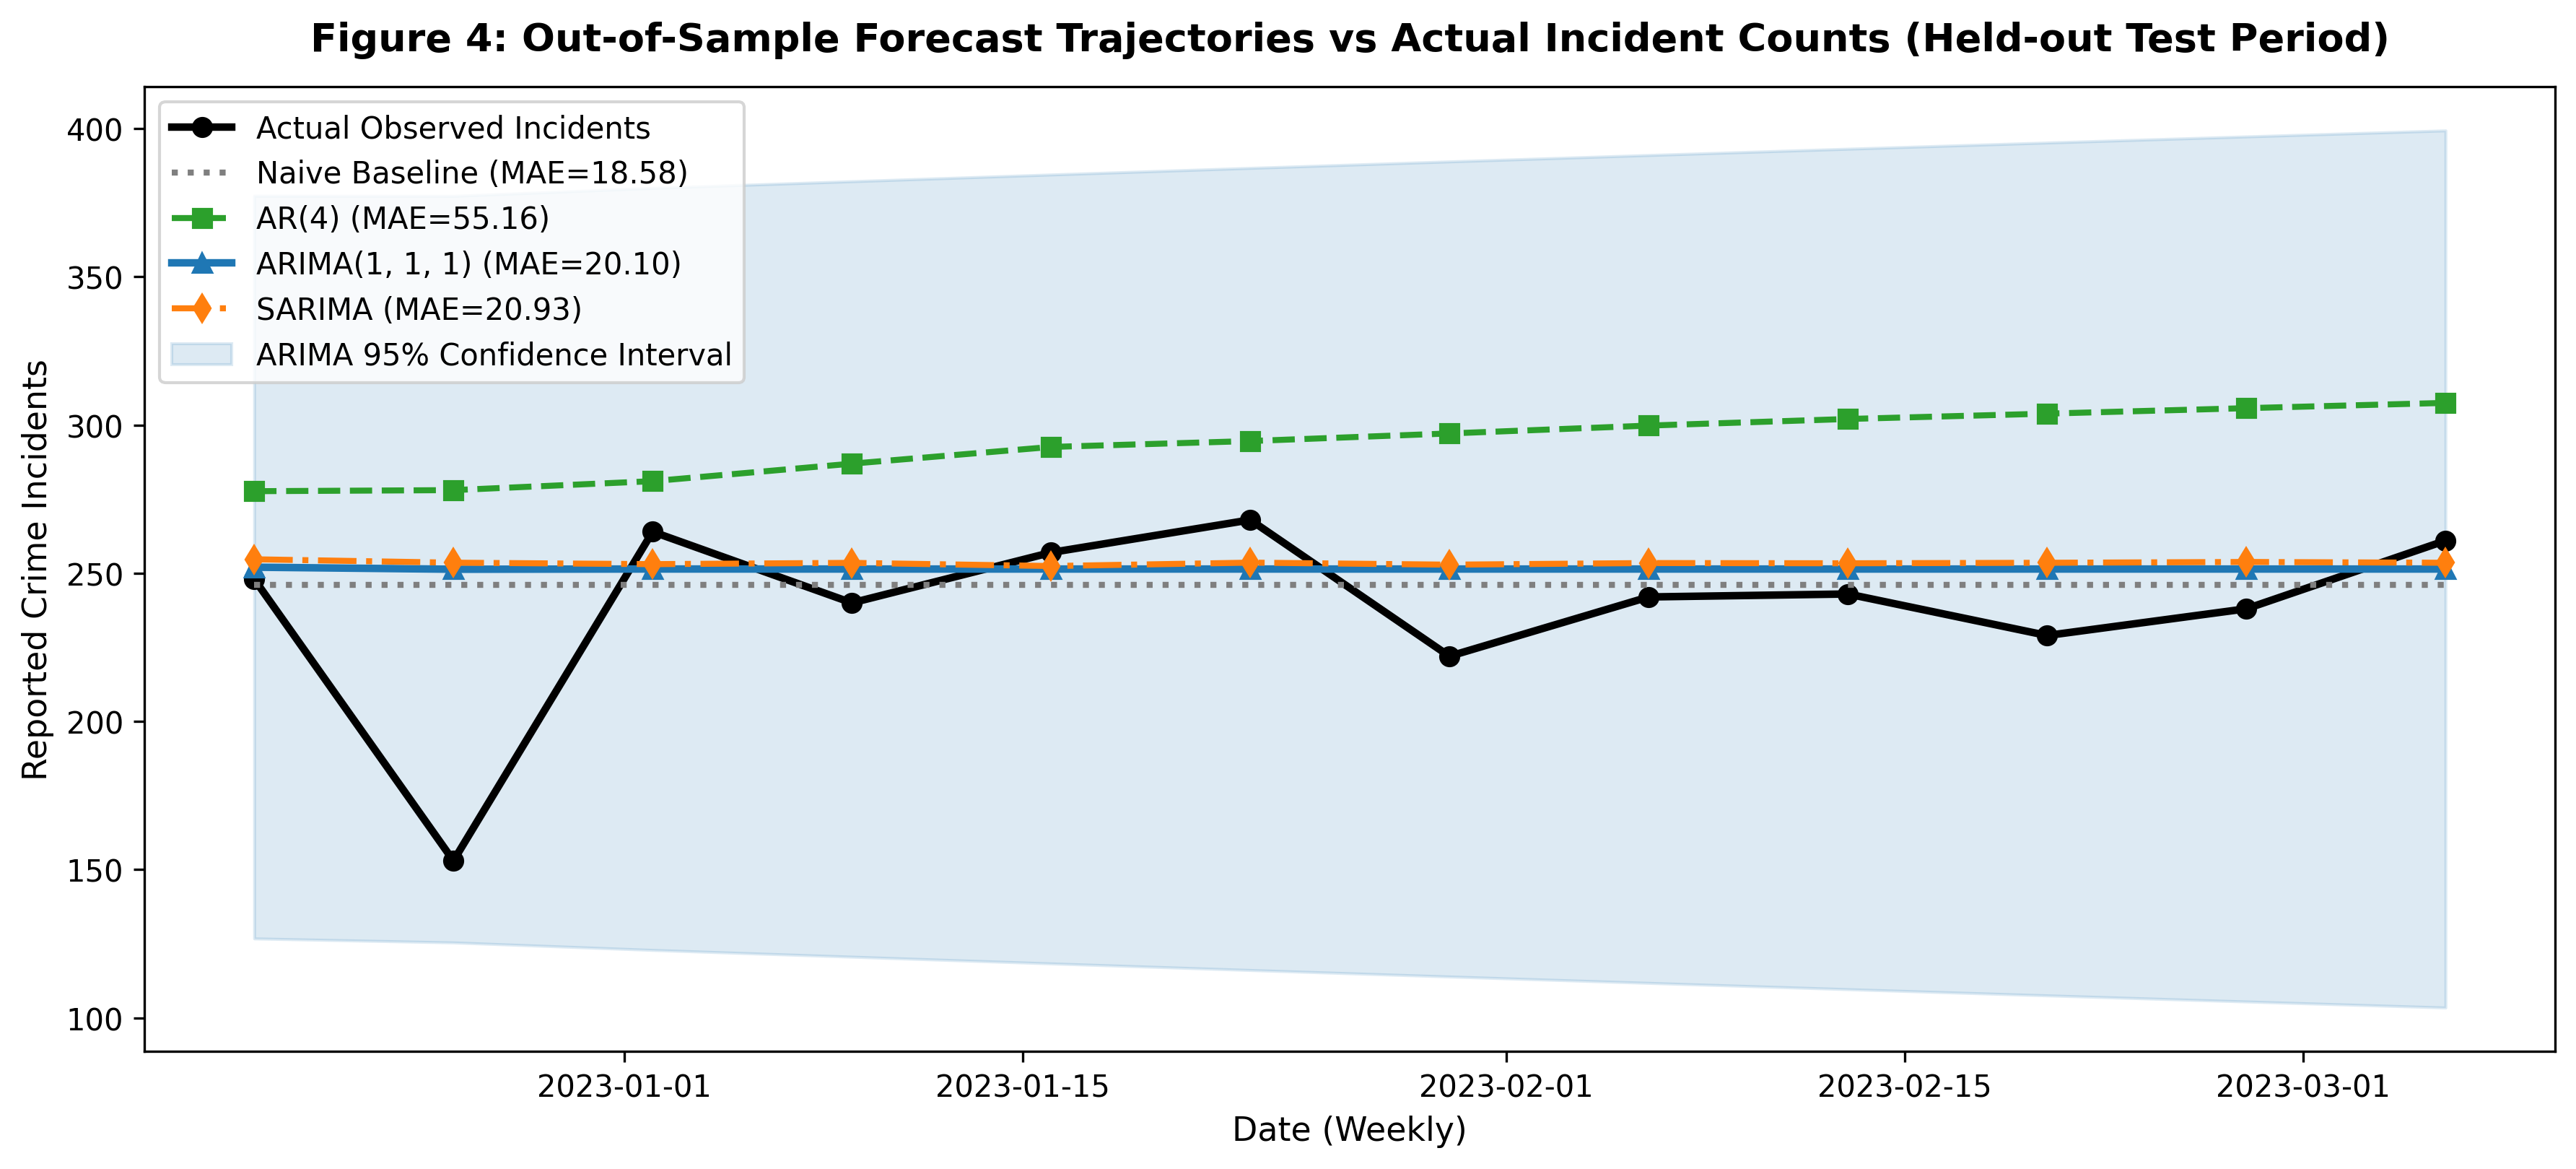

In [13]:
pred_df = pd.DataFrame({
    'actual': test_d1.values,
    'naive': naive_pred,
    'AR': np.asarray(ar_pred),
    'ARIMA': np.asarray(arima_pred),
    'ARIMA_lower_95': arima_ci.iloc[:, 0].values,
    'ARIMA_upper_95': arima_ci.iloc[:, 1].values,
    'SARIMA': np.asarray(sarima_pred),
    'SARIMA_lower_95': sarima_ci.iloc[:, 0].values,
    'SARIMA_upper_95': sarima_ci.iloc[:, 1].values
}, index=test_d1.index)

pred_df.to_csv(ANALYSIS_DIR / 'test_predictions.csv')

plt.figure(figsize=(12, 5.5), dpi=300)
plt.plot(test_d1.index, pred_df['actual'], marker='o', color='#000000', lw=2.5, label='Actual Observed Incidents')
plt.plot(test_d1.index, pred_df['naive'], linestyle=':', color='#7f7f7f', lw=2, label=f"Naive Baseline (MAE={naive_metrics['MAE']:.2f})")
plt.plot(test_d1.index, pred_df['AR'], marker='s', linestyle='--', color='#2ca02c', lw=2, label=f"AR({CONFIG['ar_lags']}) (MAE={ar_metrics['MAE']:.2f})")
plt.plot(test_d1.index, pred_df['ARIMA'], marker='^', linestyle='-', color='#1f77b4', lw=2.5, label=f"ARIMA{best_arima_order} (MAE={arima_metrics['MAE']:.2f})")
plt.plot(test_d1.index, pred_df['SARIMA'], marker='d', linestyle='-.', color='#ff7f0e', lw=2, label=f"SARIMA (MAE={sarima_metrics['MAE']:.2f})")
plt.fill_between(test_d1.index, pred_df['ARIMA_lower_95'], pred_df['ARIMA_upper_95'], color='#1f77b4', alpha=0.15, label='ARIMA 95% Confidence Interval')
plt.title('Figure 4: Out-of-Sample Forecast Trajectories vs Actual Incident Counts (Held-out Test Period)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Date (Weekly)', fontsize=11)
plt.ylabel('Reported Crime Incidents', fontsize=11)
plt.legend(frameon=True, facecolor='white', loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig04_forecast_comparison.png')
plt.show()

## 14. Residual Diagnostics and Model Adequacy Tests

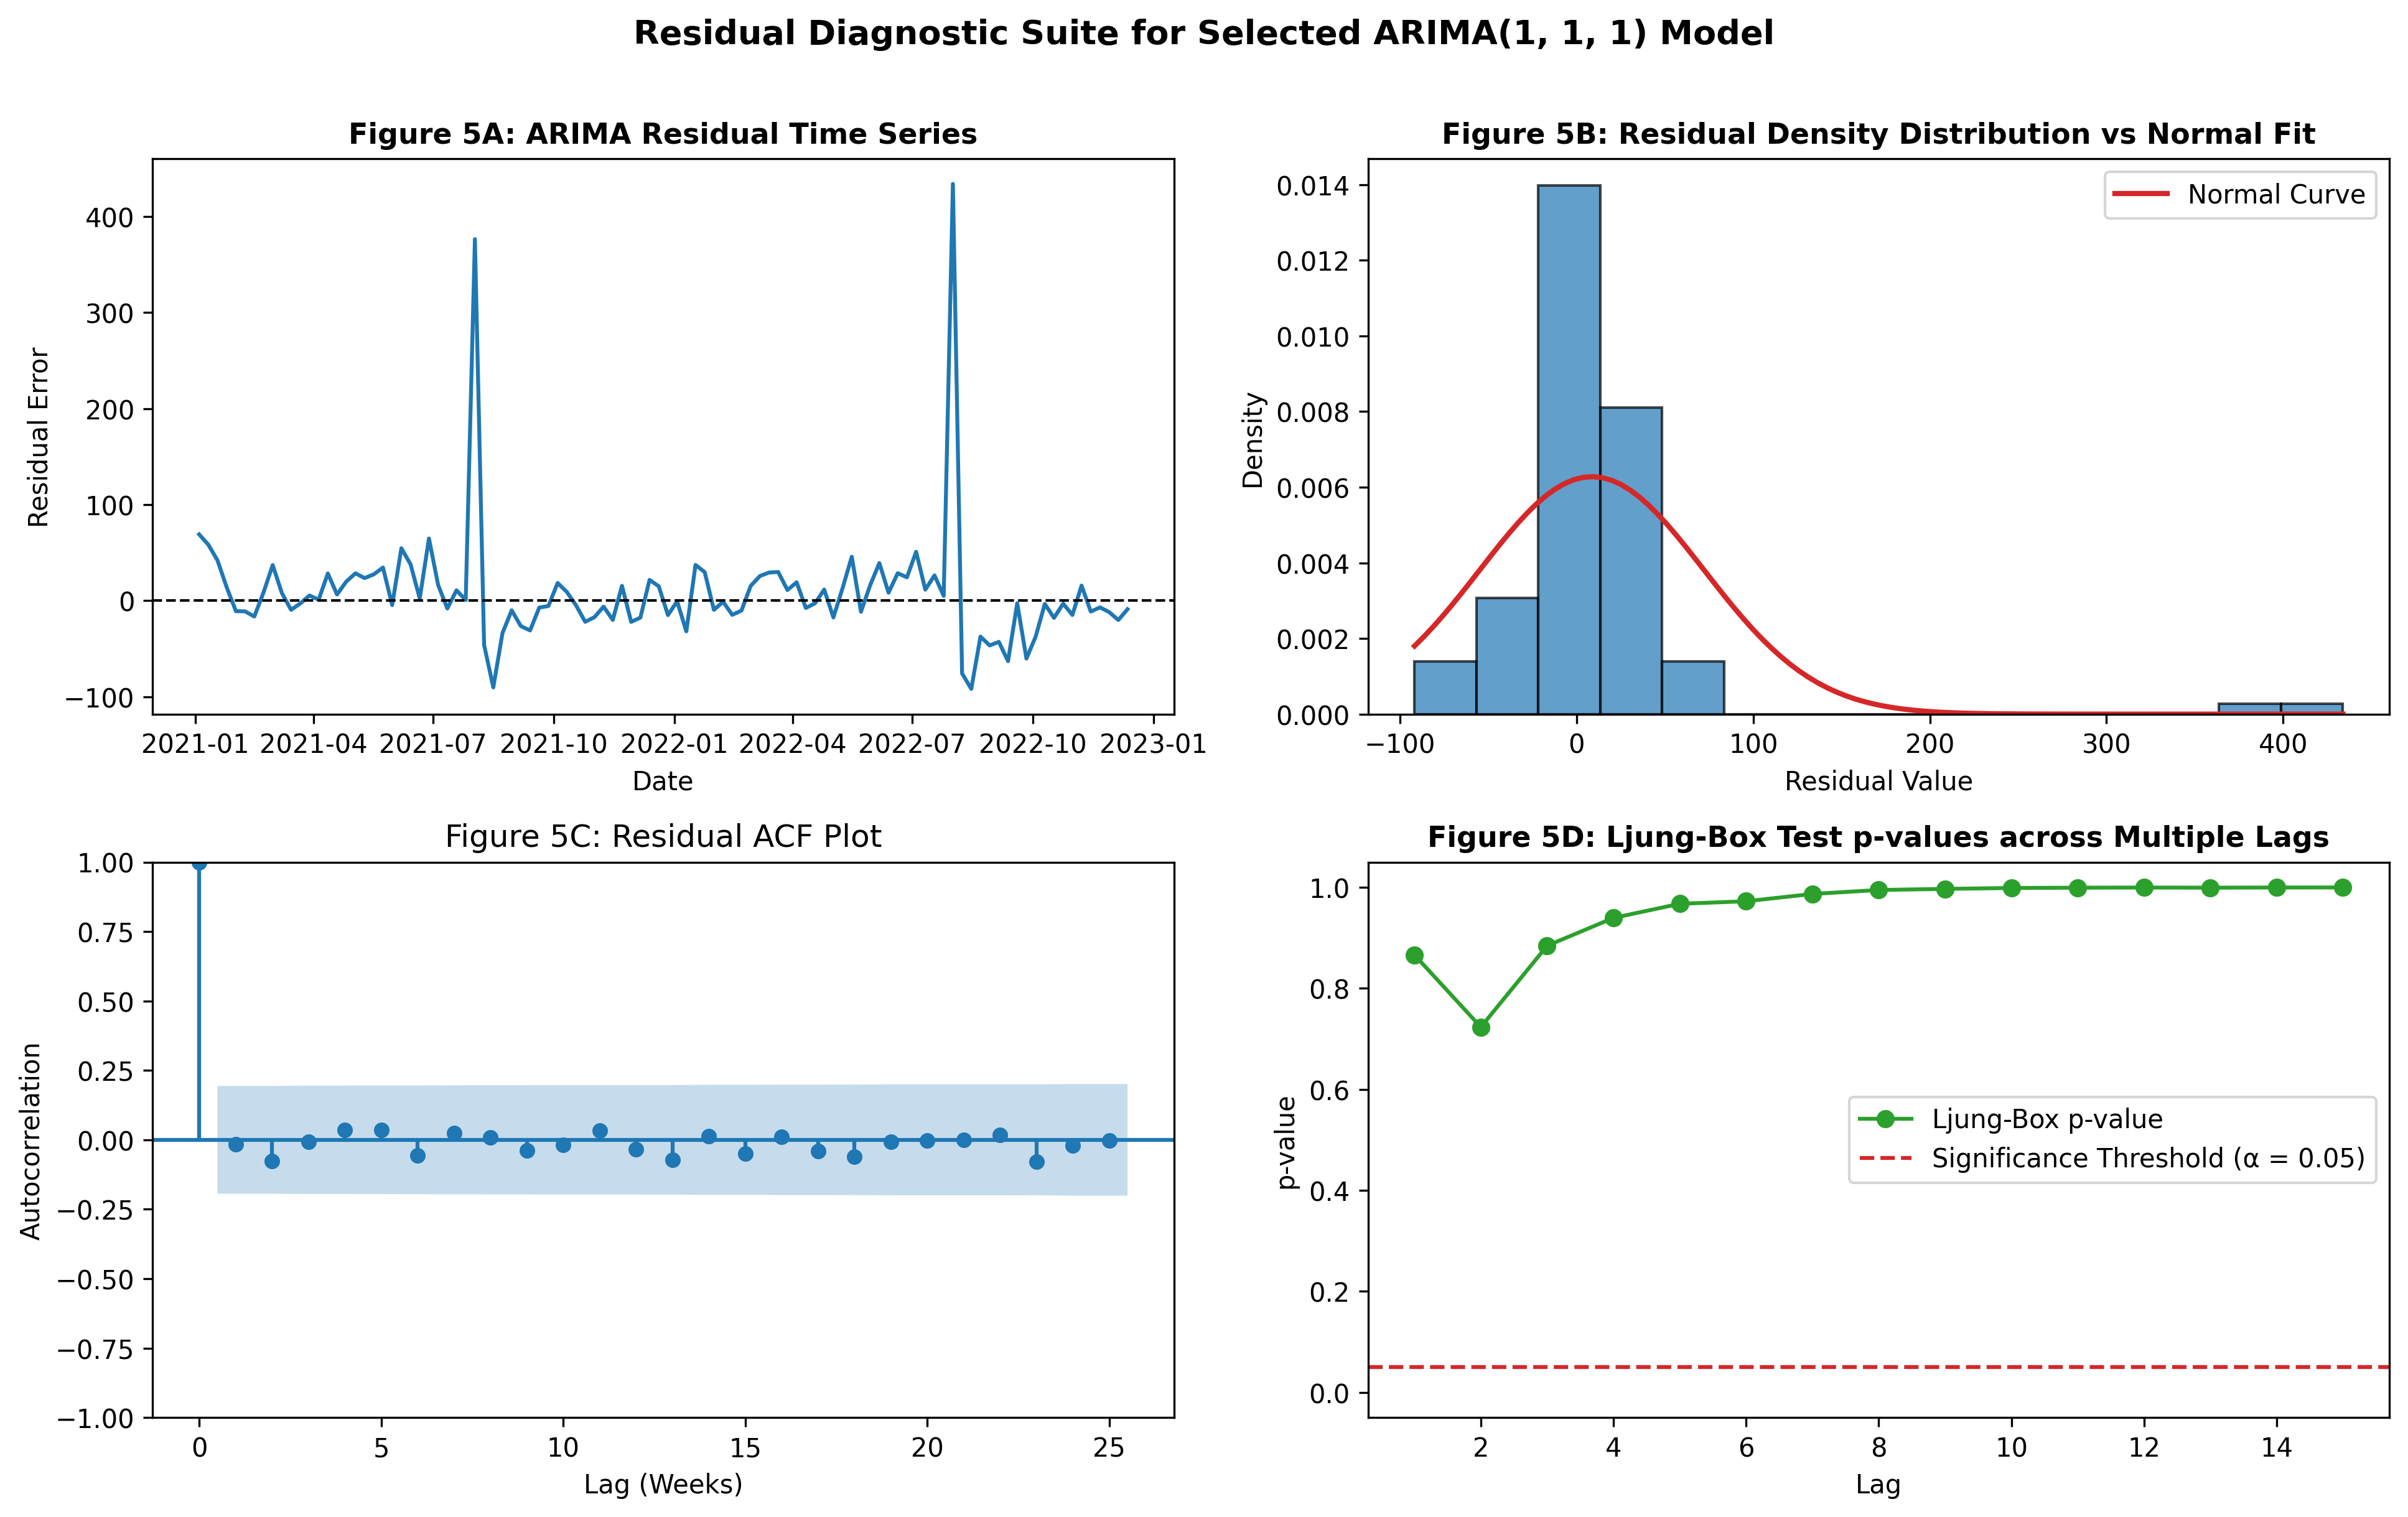

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8), dpi=300)
ax[0, 0].plot(train_d1.index[len(train_d1)-len(arima_resid):], arima_resid.values, color='#1f77b4', lw=1.5)
ax[0, 0].axhline(0, color='black', linestyle='--', lw=1)
ax[0, 0].set_title('Figure 5A: ARIMA Residual Time Series', fontsize=11, fontweight='bold')
ax[0, 0].set_xlabel('Date', fontsize=10)
ax[0, 0].set_ylabel('Residual Error', fontsize=10)

ax[0, 1].hist(arima_resid.values, bins=15, color='#1f77b4', edgecolor='black', alpha=0.7, density=True)
kde_xs = np.linspace(arima_resid.min(), arima_resid.max(), 100)
norm_fit = norm.pdf(kde_xs, np.mean(arima_resid), np.std(arima_resid))
ax[0, 1].plot(kde_xs, norm_fit, color='#d62728', lw=2, label='Normal Curve')
ax[0, 1].set_title('Figure 5B: Residual Density Distribution vs Normal Fit', fontsize=11, fontweight='bold')
ax[0, 1].set_xlabel('Residual Value', fontsize=10)
ax[0, 1].set_ylabel('Density', fontsize=10)
ax[0, 1].legend()

plot_acf(arima_resid, lags=min(25, len(arima_resid)//4), ax=ax[1, 0], color='#1f77b4', title='Figure 5C: Residual ACF Plot')
ax[1, 0].set_xlabel('Lag (Weeks)', fontsize=10)
ax[1, 0].set_ylabel('Autocorrelation', fontsize=10)

lb_full = acorr_ljungbox(arima_resid, lags=15, return_df=True)
ax[1, 1].plot(lb_full.index, lb_full['lb_pvalue'], marker='o', color='#2ca02c', lw=1.5, label='Ljung-Box p-value')
ax[1, 1].axhline(0.05, color='#d62728', linestyle='--', lw=1.5, label='Significance Threshold (α = 0.05)')
ax[1, 1].set_title('Figure 5D: Ljung-Box Test p-values across Multiple Lags', fontsize=11, fontweight='bold')
ax[1, 1].set_xlabel('Lag', fontsize=10)
ax[1, 1].set_ylabel('p-value', fontsize=10)
ax[1, 1].set_ylim(-0.05, 1.05)
ax[1, 1].legend()

plt.suptitle(f"Residual Diagnostic Suite for Selected ARIMA{best_arima_order} Model", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig05_residual_diagnostics.png')
plt.show()

## 15. Cross-Location Replication (District 1 vs District 18)

,Location,Periods,Mean Count,Std Dev,Best Model,MAE,RMSE,Interpretation
0,District 1 (Central / Downtown Loop),114,215.99,76.10,"ARIMA(1, 1, 1)",20.101,31.731,Commercial downtown corridor with high foot tr...
1,District 18 (Near North / Magnificent Mile),114,218.74,51.12,"ARIMA(1, 1, 1)",27.275,33.631,Tourism and retail district exhibiting strong ...


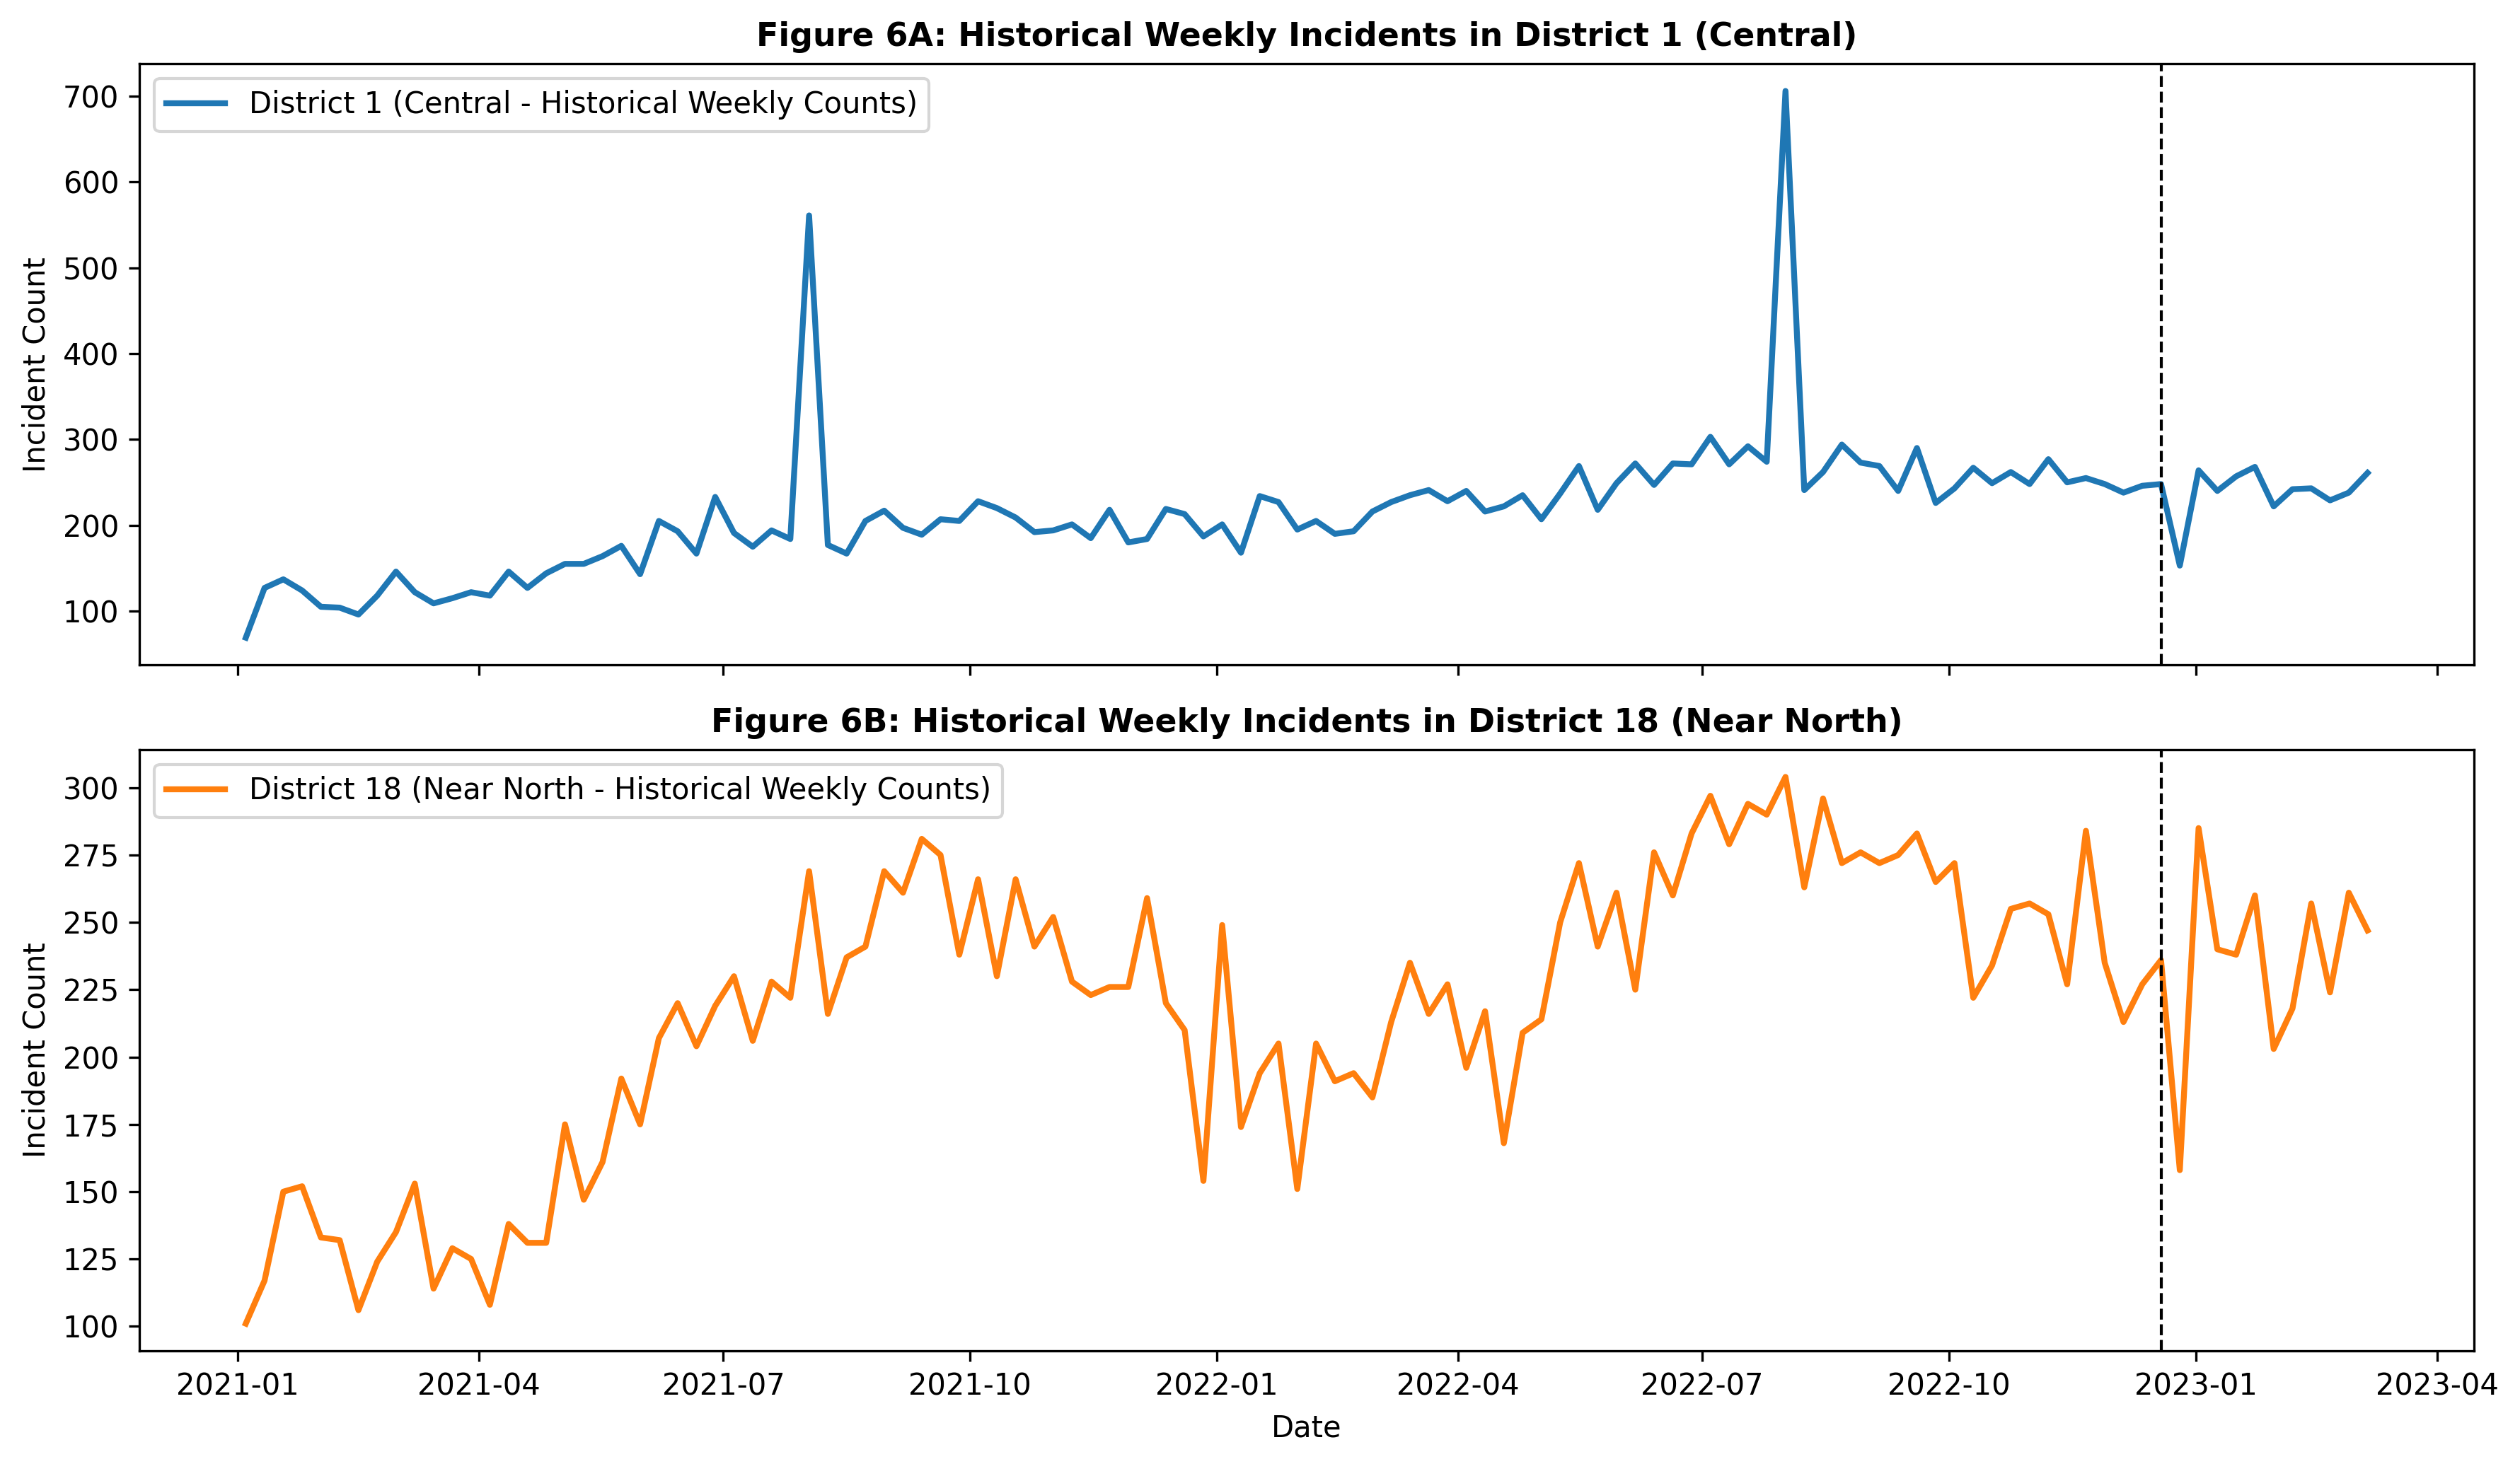

In [15]:
train_d18, test_d18 = y_d18.iloc[:-H], y_d18.iloc[-H:]
d18_arima = ARIMA(train_d18, order=best_arima_order).fit()
d18_pred = d18_arima.forecast(steps=len(test_d18))
d18_metrics = score_metrics(test_d18, d18_pred)

loc_comp_df = pd.DataFrame([
    {
        'Location': 'District 1 (Central / Downtown Loop)',
        'Periods': int(len(y_d1)),
        'Mean Count': round(float(y_d1.mean()), 2),
        'Std Dev': round(float(y_d1.std()), 2),
        'Best Model': f"ARIMA{best_arima_order}",
        'MAE': round(arima_metrics['MAE'], 3),
        'RMSE': round(arima_metrics['RMSE'], 3),
        'Interpretation': 'Commercial downtown corridor with high foot traffic and seasonal commercial volatility'
    },
    {
        'Location': 'District 18 (Near North / Magnificent Mile)',
        'Periods': int(len(y_d18)),
        'Mean Count': round(float(y_d18.mean()), 2),
        'Std Dev': round(float(y_d18.std()), 2),
        'Best Model': f"ARIMA{best_arima_order}",
        'MAE': round(d18_metrics['MAE'], 3),
        'RMSE': round(d18_metrics['RMSE'], 3),
        'Interpretation': 'Tourism and retail district exhibiting strong summer/holiday seasonal peaks'
    }
])
loc_comp_df.to_csv(ANALYSIS_DIR / 'location_comparison.csv', index=False)
display(loc_comp_df)

fig, ax = plt.subplots(2, 1, figsize=(12, 7), dpi=300, sharex=True)
ax[0].plot(y_d1.index, y_d1.values, color='#1f77b4', lw=2, label='District 1 (Central - Historical Weekly Counts)')
ax[0].axvline(test_d1.index[0], color='black', linestyle='--', lw=1)
ax[0].set_title('Figure 6A: Historical Weekly Incidents in District 1 (Central)', fontsize=11, fontweight='bold')
ax[0].set_ylabel('Incident Count', fontsize=10)
ax[0].legend(frameon=True, facecolor='white', loc='upper left')

ax[1].plot(y_d18.index, y_d18.values, color='#ff7f0e', lw=2, label='District 18 (Near North - Historical Weekly Counts)')
ax[1].axvline(test_d18.index[0], color='black', linestyle='--', lw=1)
ax[1].set_title('Figure 6B: Historical Weekly Incidents in District 18 (Near North)', fontsize=11, fontweight='bold')
ax[1].set_xlabel('Date', fontsize=10)
ax[1].set_ylabel('Incident Count', fontsize=10)
ax[1].legend(frameon=True, facecolor='white', loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig06_cross_location_comparison.png')
plt.show()

## 16. Advanced Rolling-Origin Backtesting

,Fold,Train_Size,Test_Horizon,MAE,RMSE
0,1,57,8,18.747,21.529
1,2,65,8,14.932,20.263
2,3,73,8,40.688,44.466
3,4,81,8,67.192,153.982
4,5,89,8,30.871,35.684
5,6,97,8,25.400,41.387
6,7,105,8,12.122,15.267


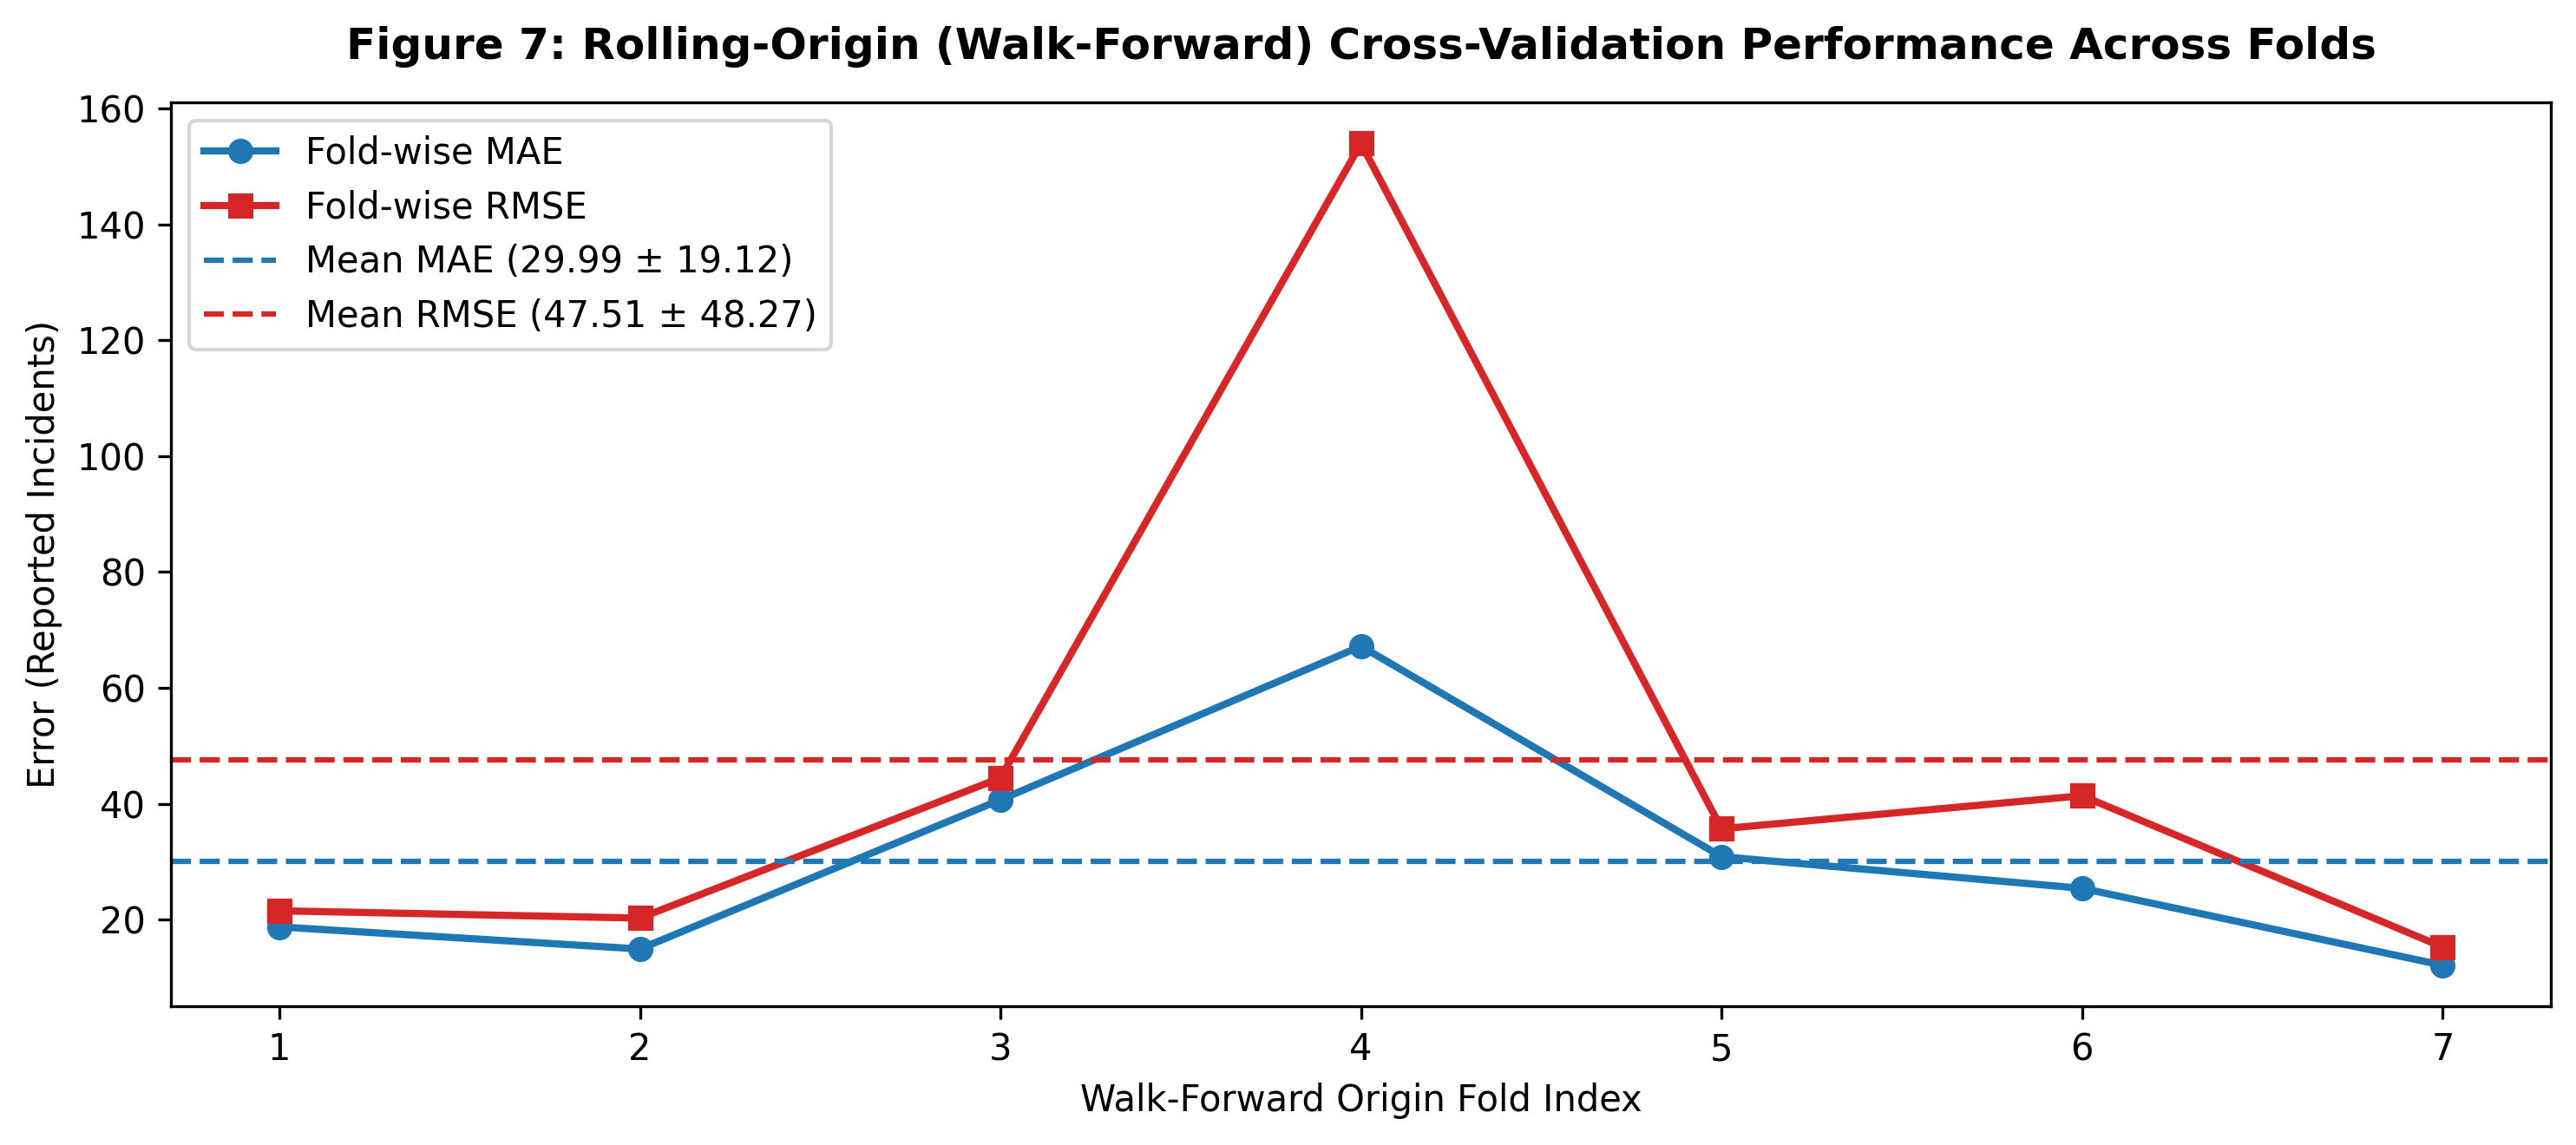

In [16]:
def rolling_origins(series, initial, horizon, step):
    origins = []
    end = initial
    while end + horizon <= len(series):
        origins.append((series.iloc[:end], series.iloc[end:end+horizon]))
        end += step
    return origins

ro_folds = rolling_origins(y_d1, initial=max(52, len(y_d1)//2), horizon=8, step=8)
ro_results = []

for fold, (tr, te) in enumerate(ro_folds, 1):
    try:
        m = ARIMA(tr, order=best_arima_order).fit()
        pr = m.forecast(len(te))
        scores = score_metrics(te, pr)
        ro_results.append({
            'Fold': fold,
            'Train_Size': len(tr),
            'Test_Horizon': len(te),
            'MAE': round(scores['MAE'], 3),
            'RMSE': round(scores['RMSE'], 3)
        })
    except Exception as e:
        print(f"Fold {fold} error: {e}")

ro_df = pd.DataFrame(ro_results)
ro_df.to_csv(ANALYSIS_DIR / 'rolling_origin_results.csv', index=False)
display(ro_df)

plt.figure(figsize=(10, 4.5), dpi=300)
plt.plot(ro_df['Fold'], ro_df['MAE'], marker='o', color='#1f77b4', lw=2, label='Fold-wise MAE')
plt.plot(ro_df['Fold'], ro_df['RMSE'], marker='s', color='#d62728', lw=2, label='Fold-wise RMSE')
plt.axhline(ro_df['MAE'].mean(), color='#1f77b4', linestyle='--', lw=1.5, label=f"Mean MAE ({ro_df['MAE'].mean():.2f} ± {ro_df['MAE'].std():.2f})")
plt.axhline(ro_df['RMSE'].mean(), color='#d62728', linestyle='--', lw=1.5, label=f"Mean RMSE ({ro_df['RMSE'].mean():.2f} ± {ro_df['RMSE'].std():.2f})")
plt.title('Figure 7: Rolling-Origin (Walk-Forward) Cross-Validation Performance Across Folds', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Walk-Forward Origin Fold Index', fontsize=10)
plt.ylabel('Error (Reported Incidents)', fontsize=10)
plt.xticks(ro_df['Fold'])
plt.legend(frameon=True, facecolor='white', loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig07_rolling_origin_cv.png')
plt.show()

## 17. Acceptance Tests and Manifest Generation

In [17]:
assert y_d1.index.is_monotonic_increasing
assert y_d1.index.is_unique
assert y_d1.isna().sum() == 0
assert len(train_d1) + len(test_d1) == len(y_d1)
assert train_d1.index.max() < test_d1.index.min()
assert len(test_d1) == CONFIG['test_periods']
assert set(['actual', 'naive', 'AR', 'ARIMA']).issubset(pred_df.columns)
assert (ANALYSIS_DIR / 'model_comparison.csv').exists()
assert (ANALYSIS_DIR / 'test_predictions.csv').exists()
assert (ANALYSIS_DIR / 'location_comparison.csv').exists()
assert (ANALYSIS_DIR / 'rolling_origin_results.csv').exists()

manifest = {
    'experiment_name': 'Experiment 06 - Time-Series Analysis and Forecasting of Reported Crime Incidents',
    'student_name': 'Raghav Mritunajaya KS',
    'registration_number': '23MID0078',
    'faculty': 'Dr. Durgesh Kumar',
    'course': 'MDI3003 - Advanced Predictive Analytics',
    'dataset_source': CONFIG['dataset'],
    'api_endpoint': CONFIG['api_endpoint'],
    'primary_district': CONFIG['primary_district'],
    'secondary_district': CONFIG['secondary_district'],
    'frequency': CONFIG['frequency'],
    'total_periods_d1': int(len(y_d1)),
    'train_periods_d1': int(len(train_d1)),
    'test_periods_d1': int(len(test_d1)),
    'adf_statistic': round(float(adf_res[0]), 4),
    'adf_pvalue': round(float(adf_res[1]), 4),
    'selected_ar_lags': CONFIG['ar_lags'],
    'selected_arima_order': list(best_arima_order),
    'best_arima_aic': round(float(best_arima_entry['AIC']), 3),
    'naive_test_mae': round(float(naive_metrics['MAE']), 3),
    'ar_test_mae': round(float(ar_metrics['MAE']), 3),
    'arima_test_mae': round(float(arima_metrics['MAE']), 3),
    'sarima_test_mae': round(float(sarima_metrics['MAE']), 3),
    'rolling_origin_mean_mae': round(float(ro_df['MAE'].mean()), 3),
    'rolling_origin_std_mae': round(float(ro_df['MAE'].std()), 3),
    'python_version': sys.version,
    'platform': platform.platform()
}

with open(OUT_DIR / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

with open(ANALYSIS_DIR / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print("Core Acceptance Tests Passed Successfully.")

Core Acceptance Tests Passed Successfully.
